Добрый день! Команда УИИ рада приветствовать вас на очередном занятии по интеграции, посвященному docker-контейнерам.

В этом уроке мы рассмотрим такое понятие как контейнеризация и разберемся как пользоваться Docker'ом – наиболее популярной системой управления контейнерами.

# Теоретическая часть

## **Что такое Docker и зачем он нужен?**

**Docker** — это платформа для разработки, доставки и запуска приложений в изолированных средах, называемых контейнерами. Контейнеры позволяют упаковать приложение со всеми его зависимостями в стандартизированную единицу для программного обеспечения. Это обеспечивает, что приложение будет работать одинаково в любой среде, независимо от различий между разработкой и стейджингом или продакшен средами.

**Зачем нужен Docker?**
1. **Согласованность и изоляция:** Docker обеспечивает согласованность среды разработки, тестирования и продакшена. Контейнеры изолируют приложения друг от друга и от хост-системы, что уменьшает конфликты между приложениями и упрощает управление зависимостями.

2. **Быстрая разработка и развертывание:** Docker упрощает процесс разработки и развертывания приложений благодаря использованию контейнеров, которые могут быть быстро созданы, модифицированы и уничтожены без риска для основной операционной системы.

3. **Портативность:** Поскольку Docker контейнеры работают одинаково в любой среде, разработчики могут быть уверены, что если приложение работает на их локальной машине, оно будет работать и на других машинах, независимо от локальных настроек и установленного программного обеспечения.

4. **Масштабируемость и управляемость:** Docker поддерживает масштабируемость и автоматизацию с помощью оркестрации контейнеров, что позволяет управлять множеством контейнеров как единой системой.

5. **Эффективность использования ресурсов:** Контейнеры требуют меньше ресурсов, чем традиционные или виртуальные машины, поскольку они не требуют отдельной операционной системы. Это повышает эффективность использования серверов и снижает затраты.

> В совокупности, Docker предоставляет мощный инструментарий для разработчиков и системных администраторов, упрощая процессы разработки, тестирования, развертывания и масштабирования приложений в современных IT-инфраструктурах.









## **Виртуализация и контейнеризация**

Контейнеризация тесно связана с использованием виртуальных машин. Виртуальные машины, как правило, применяются для разворачивания целых операционных систем (Linux, Windows, MacOS) в рамках другой платформы или сервера.

Вместе с очевидным преимуществом в виде возможности вести разработку и тестирование на требуемой операционной системе, виртуальные машины обладают и рядом недостатков:
1. Виртуальная машина занимает много места. При этом, если нам нужно запускать только одно конкретное приложение, то выделенные ресурсы окажутся избыточными – большей частью программного обеспечения мы попросту никогда не воспользуемся.
2. На загрузку виртуальной машины уходит значительное время. Это напрямую вытекает из первого пункта.
3. Запуск нескольких виртуальных машин может приводить к нестабильной производительности (конфликты при распределении ресурсов между разными виртуальными машинами).  
4. Проблема переноса между различными средами. То есть если мы захотим перенести некое приложение с одной виртуальной машины на другую, то это потребует установки и настройки программного обеспечения с нуля.

Контейнеризация – это по сути тоже виртуализация, но на уровень ниже.  

В контейнерах уже не содержится операционная система и весь набор библиотек, необходимых для функционирования системы. В контейнере мы держим конкретное приложение и только те библиотеки, которые этим приложением используются.

Преимущества работы с контейнерами:

1. Возможность запускать приложение в том же окружении. Приложение будет работать как на собственной локальной машине, так и на чужом ПК или на сервере (особенно актуально именно для серверов).  

2. При работе над разными проектами помогает избежать конфликтов между ними, полностью отделяя проекты друг от друга.  

3. Не нужно тратить время на установку и переустановку всех необходимых зависимостей.  
То есть мы можем создать один контейнер, в котором будут разворачиваться библиотеки tensorflow 1.15, numpy 1.14.0 и другой контейнер, в котором будут уже другие версии библиотек: tensorflow 2.6.0, numpy 1.19.5. Благодаря этому для каждой задачи мы можем создать ее собственное окружение и в дальнейшем при переключении между задачами уже не заниматься обновлением/откатом библиотек к нужным версиям.

4. Загрузка контейнера занимает доли секунд. Контейнеры легче и быстрее виртуальных машин.

Пока что мы описали контейнеризацию в общем виде. Теперь посмотрим как реализована работа с контейнерами в Docker.

## **Состав Docker**

Как уже было отмечено в самом начале Docker – это система управления контейнерами, которая устанавливается поверх основной операционной системы. Docker состоит из трех основных составляющих: Dockerfile, Docker Image и Docker Сontainer. Операции с Docker осуществляются с помощью сервиса Docker Daemon. Сейчас опишем это всё более подробно.

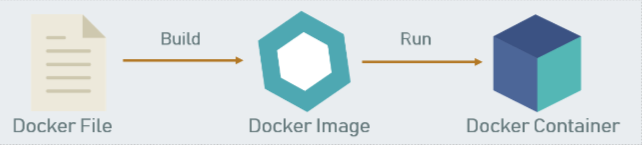

**Dockerfile** – это текстовый документ, который содержит все команды, которые пользователь может вызывать в командной строке для сборки Docker Image. Таким образом, Docker может создавать Image автоматически, читая инструкции из Dockerfile. Сам Dockerfile можно представить в виде слоев:   

- Сначала в Docker-файле идет описание базового образа, который будет представлять собой исходный слой образа (это может быть, например, Python)

- Поверх базового образа добавляются дополнительные слои. Например, если Dockerfile описывает образ, который планируется использовать для запуска нейронной сети, то в нём могут быть инструкции для включения в промежуточный слой такого образа библиотек Numpy, TensorFlow, Keras и т.д.

- И также в образе может содержаться слой с данными, которые поддаются изменению. Это небольшой по объёму слой, содержащий программу, которую планируется запускать в контейнере.



**Docker Image** (или образ). Docker-образ можно сравнить с шаблоном, который используется для создания Docker-контейнеров. Эти шаблоны являются строительными блоками Docker контейнера. Образ содержит все необходимое программное обеспечение, которое необходимо для запуска приложения (код, библиотеки, переменные окружения и конфигурационные файлы).

Образы хранятся в реестре Docker. Это может быть либо локальный репозиторий пользователя, либо общедоступный репозиторий, такой как Docker Hub. К Docker Hub мы еще обратимся в практической части.

**Docker Container** (или контейнер) – это запущенный экземпляр образа Docker. Он также содержит весь пакет, необходимый для запуска приложения. Именно контейнером мы в конечном итоге и будем оперировать.  

Во время выполнения контейнера Docker внутри него обычно выполняется какая-то программа. Она выполняет в контейнере некие действия. Например, принимает изображение, передает в нейронную сеть и возвращает распознанный класс.

Из одного образа можно создать множество контейнеров. Все эти контейнеры будут запускать идентичный код.  

Docker-контейнер можно запускать и останавливать по своему усмотрению и все изменения, которые вносятся в контейнере (например, создание/изменение файлов) сохранятся. При этом внесенные изменения не влияют на сам Docker-образ и существуют только внутри контейнера.

**Docker Daemon** (демон Docker'а) – фоновый сервис, который отвечает за создание, запуск и уничтожение Docker-контейнеров. Демон — это процесс, который запущен на операционной системе.

Если сравнить запуск контейнера с приготовлением пищи, то Dockerfile – это рецепт приготовления блюда, Docker Image – это ингредиенты для приготовления, а Docker Сontainer – это готовое блюдо. При этом, блюдо нужно где-то приготовить (на плите или в духовке) – это Docker Daemon.

## **Docker Compose**


**Что такое Docker Compose и для чего он используется?**

**Docker Compose** — это инструмент для определения и управления многоконтейнерными Docker приложениями. С помощью Compose вы используете YAML файл для конфигурирования сервисов вашего приложения. Затем, с помощью одной команды, создаёте и запускаете все сервисы из вашей конфигурации. Это особенно полезно в процессах разработки, тестирования и стейджинга, где необходимо запустить приложение с несколькими сервисами, которые должны взаимодействовать друг с другом.

**Основы конфигурации с помощью файла docker-compose.yml**
Файл docker-compose.yml используется для конфигурации параметров, которые обычно были бы переданы в Docker через командную строку. Вот основные секции и параметры, которые можно определить в этом файле:

**version:** Указывает версию Docker Compose файла.

**services:** Основная секция, где определяются контейнеры, их зависимости, порты и другие параметры.

**image:** Имя образа, который будет использоваться для контейнера.

**build:** Путь к директории, содержащей Dockerfile, если вы хотите собрать образ самостоятельно.

**ports:** Список портов, которые будут открыты и связаны с хостом.

**volumes:** Список томов для хранения данных, необходимых контейнеру.

**environment:** Переменные окружения, доступные в контейнере.

**depends_on:** Список сервисов, от которых зависит данный сервис.

**command:** Команда, которая будет выполнена при запуске контейнера.


***Пример файла docker-compose.yml:***

In [ ]:
version: '3.8'
services:
  web:
    image: nginx:latest
    ports:
      - "80:80"
    volumes:
      - ./data:/usr/share/nginx/html
  database:
    image: postgres:latest
    environment:
      POSTGRES_PASSWORD: example


**Управление многоконтейнерными приложениями**

**Docker Compose упрощает** управление многоконтейнерными приложениями, позволяя запускать, останавливать и перестраивать сервисы одной командой. Вот основные команды для управления приложениями с помощью Docker Compose:

**docker-compose up:** Запускает все сервисы, определенные в docker-compose.yml. Если добавить флаг -d, сервисы будут запущены в фоновом режиме.

**docker-compose down:** Останавливает все запущенные сервисы и удаляет контейнеры, сети, тома и образы, созданные при запуске.

**docker-compose build:** Пересобирает образы, для которых в конфигурации указана сборка.

**docker-compose logs:** Показывает логи от всех сервисов. Флаг -f позволяет следить за логами в реальном времени.

Использование Docker Compose значительно упрощает процесс разработки и деплоя приложений, состоящих из множества сервисов, и помогает обеспечить их консистентность и изоляцию.

## **Примеры использования Docker в разработке**


Docker предлагает множество преимуществ для разработчиков программного обеспечения, особенно в контексте упрощения и стандартизации процессов разработки, тестирования и развертывания приложений. Ниже приведены некоторые конкретные примеры использования Docker в разработке.

**Разработка приложений с использованием Docker**
1. Консистентная разработка: Docker позволяет создать единое окружение для разработки, которое может быть точно воспроизведено на любой машине. Это избавляет от проблемы "у меня работает, а у тебя нет", так как все зависимости, библиотеки и настройки окружения упакованы в контейнер.

*Пример:* Разработчики могут использовать Docker для запуска баз данных, веб-серверов и других сервисов, необходимых для полноценной работы приложения, без необходимости установки и настройки этих компонентов на локальной машине каждого разработчика.

**Изоляция зависимостей**
2. Изоляция зависимостей: Каждый Docker контейнер работает изолированно от других, что позволяет управлять зависимостями каждого приложения отдельно. Это особенно полезно, когда разные проекты требуют разных версий одной и той же библиотеки.

*Пример:* Если одно приложение требует Python 2.7, а другое — Python 3.12, каждое из них может быть развернуто в своем контейнере с нужной версией Python, без конфликтов и без необходимости компромиссов в конфигурации системы разработчика.

**Упрощение развертывания и тестирования**
3. Упрощение развертывания: Docker обеспечивает простоту и скорость развертывания приложений, поскольку все окружение приложения, включая операционную систему, библиотеки и конфигурации, упаковывается в контейнер, который можно легко перемещать и запускать на любой целевой системе.

*Пример:* Разработчики могут использовать Docker для создания образов своих приложений и развертывания их в различных средах (разработка, тестирование, продакшн) без дополнительных настроек.

4. **Стандартизация тестирования:** Docker позволяет стандартизировать и автоматизировать процессы тестирования, обеспечивая, что тесты выполняются в точно таком же окружении, в котором будет работать приложение.

*Пример:* Используя Docker, можно легко настроить непрерывную интеграцию и доставку (CI/CD), где каждое изменение в коде автоматически тестируется в контейнере, а затем, если тесты проходят успешно, изменения могут быть автоматически развернуты в продакшн.

Эти примеры демонстрируют, как Docker может улучшить процессы разработки, упростить управление зависимостями и автоматизировать тестирование и развертывание приложений, делая эти процессы более предсказуемыми и менее подверженными ошибкам.

# Практическая часть 1

## Установка Docker

Важно понимать, что Docker разработан под Unix-подобные системы. То есть наиболее комфортно работать с Docker через Linux или MacOS. Но и установка Docker на Windows за последнее время значительно упростилась.  

В этом разделе собраны инструкции по установке Docker на каждую из трех самых распространенных операционных систем.

---
[Дополнительная информация (База знаний - «**Установка Docker на Windows 10**»)](https://colab.research.google.com/drive/1PltR2MELgzONpsemLQnUhT4dl6lY_KUq?usp=sharing)

---

---
[Дополнительная информация (База знаний - «**Установка Docker на Linux**»)](https://colab.research.google.com/drive/13oSSSCqV840Lx4wJTQr66US0SQubtOto?usp=sharing)

---

---
[Дополнительная информация (База знаний - «**Установка Docker на MacOS**»)](https://colab.research.google.com/drive/1Cfw6In_7AQLuCSQAYDATDnzwafuB01DK?usp=sharing)

---

## Основные команды Docker

### Docker images

Теперь, когда Docker установлен, можно приступить к работе с ним. Рассмотрим несколько основных команд Docker'а.  

Для этого перейдем в командную строку

Получить список образов можно с помощью команды:  
```docker images```

Поскольку мы только начали работу с Docker, то никаких образов еще не загружено и список соответственно будет пустым.

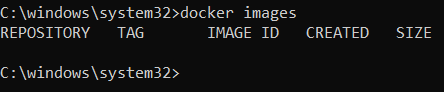

Доступные образы можно посмотреть также и в пользовательском интерфейсе Docker Desktop во вкладке Images.  
(интерфейс Docker Desktop доступен для Windows и MacOS)

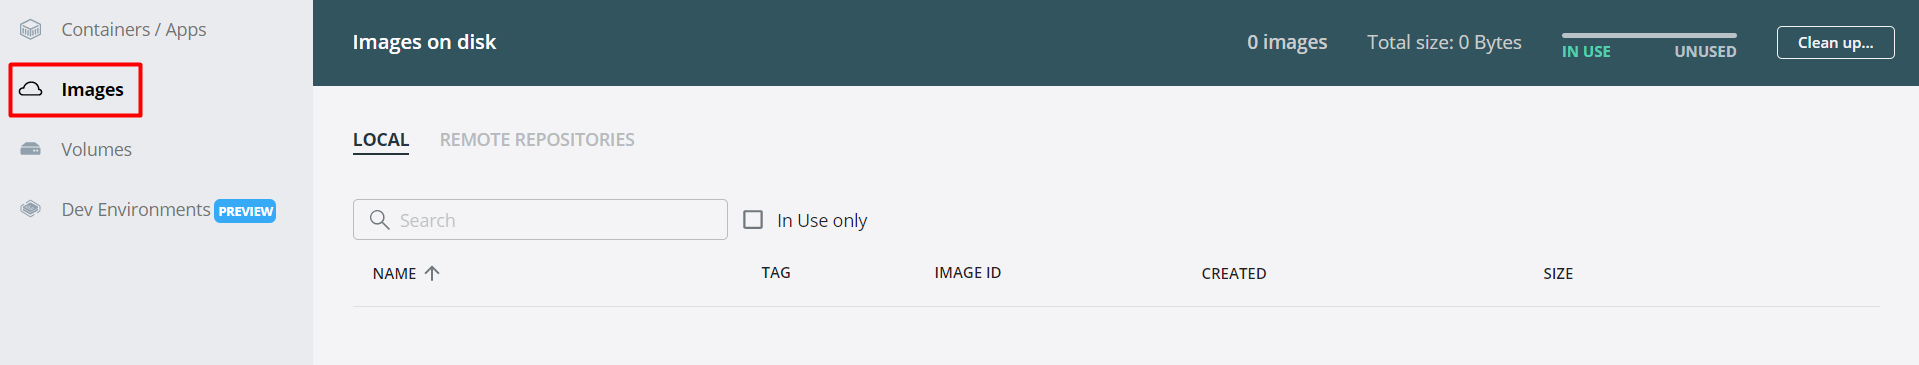

Откуда брать образы?  
1. Воспользоваться хранилищем Docker Hub – здесь уже есть большое количество готовых образов.
2. Создать самостоятельно при помощи Dockerfile.  

Давайте для начала поработаем с готовым образом, а затем разберемся как можно создать собственный образ.


### Docker pull

Начнем с самого простого – с Hello World :)  

Переходим на сайт [Docker hub](https://hub.docker.com/). В строке поиска вводим hello-world. По первой ссылке открывается страница с Docker-образом hello-world.

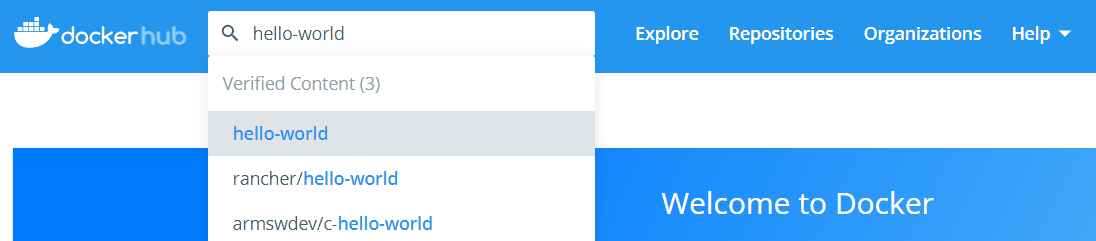

На страницах с образами в числе прочего указывается команда загрузки образа к себе в систему. В данном случае это:

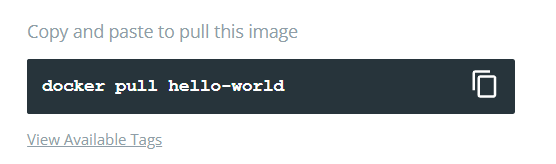

```docker pull``` – команда для скачивания образа. Далее следует имя образа ```hello-world```  

После выполнения команды образ ```hello-world``` появится в списке образов.

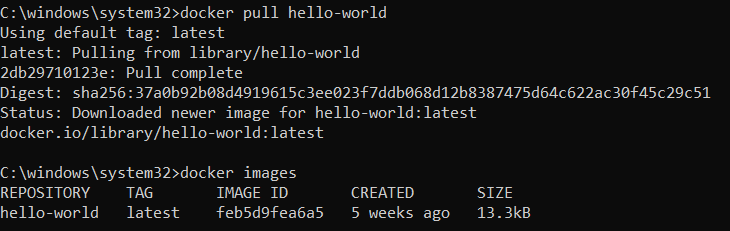

### Docker run

Для того, чтобы создать из этого образа контейнер используется команда  

```docker run hello-world```  

При создании контейнера можно сразу присвоить ему имя, чтобы в дальнейшем было удобнее обращаться к нему. Это делается путем передачи параметра ```--name```:  

```docker run --name my_container hello-world```

При этом, команда ```run``` сразу же и запускает контейнер. Результат запуска контейнера ```hello-world``` отображается там же в командной строке.  

Данный образ почти ничего не делает, только выводит некоторую текстовую информацию и подтверждение того, что контейнер создан и успешно запускается.

### Docker ps

Получить список созданных контейнеров можно командой    
```docker ps -a```  

Флаг ```-a``` означает, что будут показаны все имеющиеся в системе контейнеры (без него отображаются только запущенные в данный момент контейнеры).  

Сейчас у нас есть один контейнер. В колонке STATUS можно увидеть, что контейнер завершил свою работу.



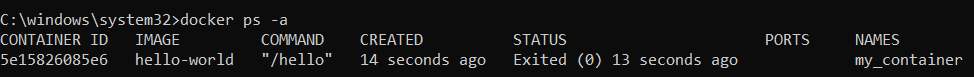

Так же как и список образов список контейнеров можно посмотреть в Docker Desktop. Вкладка Containers / Apps.

### Docker start и docker stop

Для повторного запуска контейнера используйте команду  
```docker start -i CONTAINER```  

В качестве ```CONTAINER``` указывается ID или имя контейнера, которые можно узнать из списка контейнеров.  

Флаг ```-i``` запустит контейнер в интерактивном режиме. В данном случае будет повторно выведена текстовая информация. Для "более содержательных" контейнеров флаг ```-i``` даст возможность вызывать команды, доступные для контейнера.

Остановка работы контейнера осуществляется командой  
```docker stop CONTAINER```  

В случае с ```hello-world``` контейнер останавливать не нужно, поскольку он закончил работу сам сразу после вывода информации.

### Копирование файлов

Команда ```docker cp``` позволяет осуществлять копирование файлов / папок между контейнером и локальной файловой системой.

Если нужно копировать данные из контейнера на локальную систему:    

```docker cp CONTAINER:SRC_PATH DEST_PATH```

В качестве ```CONTAINER``` указывается ID или имя контейнера, которые можно узнать из списка контейнеров.  
```SRC_PATH``` – это путь к файлу/папке в контейнере.  
```DEST_PATH``` – место куда нужно скопировать файл/папку.  

Если же наоборот нужно копировать данные в контейнер, нужно вызвать:

```docker cp SRC_PATH CONTAINER:DEST_PATH```

### Удаление контейнеров и образов

Для того, чтобы удалить контейнер, используется команда:  
```docker rm CONTAINER```  

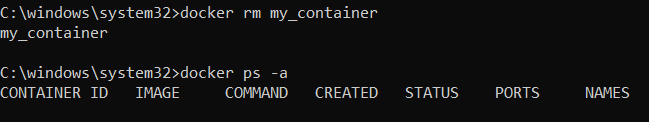

Для того, чтобы удалить образ, используется команда:  
```docker rmi IMAGE_ID```  

ID образа можно получить из списка образов.

Это основные команды, большую часть из которых понадобится использовать почти в каждой сессии работы с Docker'ом. С другими командами Docker и доступными для команд параметрами можно ознакомиться в [документации](https://docs.docker.com/engine/reference/run/).

## Создание собственного образа при помощи Dockerfile

### Python-скрипт

Давайте теперь создадим свой образ – что-то похожее на образ hello-world, который мы загружали до этого. Для этого сперва напишем скрипт Python – наше приложение.

Создайте новую директорию, где будут храниться файлы для будущего образа. В этой директории создайте файл с расширением ```.py``` и дайте ему название, например, ```my_app.py```

В ```py```-файле напишите следующий код:  

```print('Hello World!')```

### Подготовка Dockerfile

Далее создадим Dockerfile. Как уже упоминалось, Dockerfile – это обычный текстовый файл. Только без расширения ```.txt```. Так что в той же директории, где лежит ```my_app.py```, создаем текстовый файл, даем ему имя ```Dockerfile``` и удаляем расширение. Редактировать Dockerfile можно через любой текстовый редактор.  

В Dockerfile укажем следующие команды:  

```
FROM faucet/python3
ADD my_app.py /
CMD [ "python", "./my_app.py" ]
```



Разберем более подробно используемые команды.

* ```FROM``` – устанавливает базовый образ для последующих инструкций. В данном случае мы установили Python версии 3 из репозитория ```faucet``` в качестве базового образа. Теперь Dockerfile получит этот базовый образ из Docker Hub.  
Вы можете использовать и другой базовый образ Python. Найти их можно всё там же на Docker Hub, осуществив поиск по python или python3.  

* ```ADD``` – копирует новые файлы, каталоги или URL-адреса удаленных файлов из ```<src>``` и добавляет их в файловую систему образа по пути ```<destination>```. В нашем случае ```<src>``` – это ```my_app.py```, а пункт назначения – ```/``` (то есть корневая директория).

* ```CMD``` – задает команду, которая будет выполнена в командной строке при запуске контейнера. В данном случае выполнится команда по запуску нашего приложения ```python ./my_app.py```

Dockerfile готов, можно собирать образ!

### Создание и запуск образа Docker

Откройте командную строку от имени администратора и перейдите в директорию с вашим Docker-файлом. Осталось запустить всего одну команду:  

```docker build -t my-image .```  

Флаг ```-t``` или ```--tag``` позволяет дать имя нашему образу – ```my-image```  

Точка в конце команды указывает на то, что Dockerfile лежит в текущей директории. Если предварительно не переходить в папку с Dockerfile, то вместо точки нужно будет указать путь к этой папке.

Результат запуска команды ```docker build```

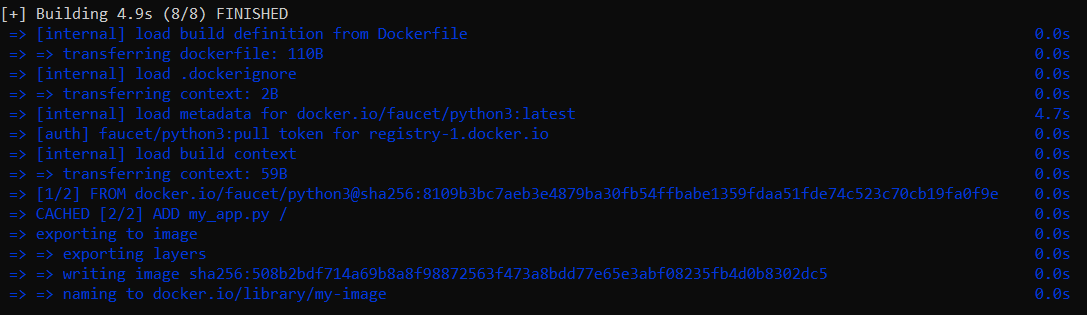

Образ получен и теперь его можно увидеть в списке образов:

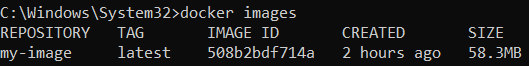

Контейнер запускается уже известной командой:  

```docker run my-image```

Результат:

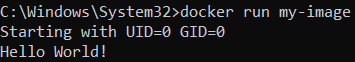

### Еще один пример создания Docker-образа

Мы уже создали и запустили собственный контейнер. Но пока никак с ним не взаимодействовали. Давайте теперь создадим еще один образ, который также будет осуществлять приветствие. Но приветствовать он будет именно нас. Для этого понадобится передать в контейнер своё имя.

И также мы познакомимся с еще одной полезной командой: ```docker exec```.

Создаем новый python-скрипт ```hello_app.py```. Теперь уже чуть более содержательный:

In [ ]:
import argparse # Модуль для извлечения аргументов, передаваемых скрипту через командную строку

# Основная функция
def say_hello(name):
    print(f'Привет, {name}')

if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='Greetings') # Создаем парсер для аргументов, переданных через командную строку
    parser.add_argument('name', type=str, help='Your name')   # Задаем один обязательный аргумент - имя
    args = parser.parse_args()                                # Парсим аргументы
    name = args.name                                          # Извлекаем имя
    say_hello(name)                                           # Передаем имя в функцию для приветствия

Передавать свое имя мы будем также через командную строку. Поэтому в скрипте понадобится вызвать модуль ```argparse```. Он нужен для передачи значений из командной строки в выполняемый скрипт.

Далее определяется функция для приветствия, в которую передается имя того с кем нужно поздороваться.

Конструкция ```if __name__ == '__main__':``` означает, что если скрипт будет вызван, то дальше выполнятся команды, указанные в теле этого условия.

Сначала будет создан парсер для извлечения аргументов из командной строки. Далее указываем, что ожидается один обязательный аргумент ```name``` (тип аргумента – строка, на что указывает значение параметра ```type```). После чего извлекаем имя из парсера, записываем в переменную и передаем в основную функцию ```say_hello```

---
[Дополнительная информация (База знаний - «**Модуль argparse**»)](https://colab.research.google.com/drive/16szjV0hMbKKQh63k_3VlD8mB_G8sgo24?usp=sharing)

---

Создадим Dockerfile для создания нового образа:

```
FROM python:3.8
ADD hello_app.py /
```

Воспользуемся другим базовым образом для Python (python:3.8).  

И здесь нам не потребуется команда ```CMD```, выполняемая при запуске контейнера. В дальнейшем мы сами обратимся к контейнеру.

Перейдем в директорию с Dockerfile и выполним команду создания образа:

```docker build -t say-hello-image .```

Далее запустим новый контейнер в интерактивном режиме (флаг ```-it```), присвоив имя ```new-container```:    

```docker run -it --name new-container say-hello-image```

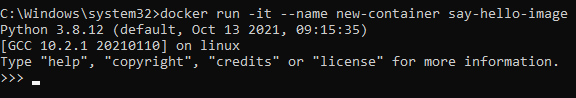

Контейнер запущен и теперь в него можно передать команду. Для этого откроем второй экземпляр командной строки и вызовем наше приложение при помощи команды ```docker exec```:  

```docker exec new-container python hello_app.py Алексей```  

Сначала указываем имя контейнера, к которому хотим обратиться (```new-container```). Далее следует команда, которую нужно выполнить: даем инструкцию Python запустить скрипт ```hello_app.py``` с одним аргументом – именем.

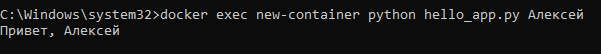

Теперь вы знаете как можно вызвать ваше приложение внутри контейнера!

Для выхода из интерактивного режима и завершения работы контейнера в командной строке, в которой запущен контейнер, нужно ввести команду ```exit()```

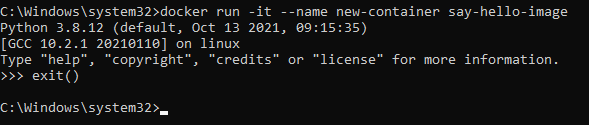

### Еще несколько команд для Dockerfile

```COPY``` – копирует файлы и каталоги из ```<src>``` и добавляет их в файловую систему образа по пути ```<destination>```. Команда похожа на команду ```ADD```, но ```ADD``` обладает дополнительной функциональностью (распаковка архивов и скачивание файлов).

```RUN``` – используется для выполнения команд из консоли. ```RUN``` может использоваться для установки необходимых зависимостей, которые потребуются для работы приложения и которых нет в базовом образе. Например: ```RUN pip install numpy```.  
Эта инструкция похожа на инструкцию ```CMD```, но есть существенное отличие:  
* ```RUN``` срабатывает, пока мы создаем образ Docker. У Dockerfile может быть много ```RUN```-шагов, которые накладываются друг на друга для построения образа.
* ```CMD``` срабатывает, когда мы запускаем созданный образ Docker. ```CMD``` является командой по умолчанию, которая будет выполняться только при запуске контейнера без указания команды.

```EXPOSE``` – сообщает какой из портов будет прослушиваться контейнером. Это команда понадобится, например, если мы разрабатываем web-приложение, которое обрабатывает приходящие REST-запросы.  
После команды указывается порт, который нужно открыть, например, ```EXPOSE 8000```  

Конечно команды для Docker-файла не ограничиваются перечисленными в этом ноутбуке. С другими командами можно также ознакомиться в [документации](https://docs.docker.com/engine/reference/builder/).

# Практическая часть 2

Давайте создадим простой Dockerfile для запуска веб-сервера на базе Nginx. Этот пример поможет вам понять основные шаги от создания Dockerfile до запуска контейнера на вашей машине с Windows 10, где установлен Docker Desktop.

**Шаг 1: Создание Dockerfile**

Откройте текстовый редактор (например, Notepad++ или Visual Studio Code).

Вставьте следующий текст, который определяет базовый образ, копирует файлы в контейнер и указывает команду для запуска сервера:

In [ ]:
# Используем официальный образ Nginx
FROM nginx:latest

# Копируем файлы из текущей директории в контейнер в папку /usr/share/nginx/html
COPY . /usr/share/nginx/html

# Открываем порт 80
EXPOSE 80

# Запускаем Nginx при старте контейнера
CMD ["nginx", "-g", "daemon off;"]


Сохраните файл с именем Dockerfile в новой папке, например, C:\Users\YourUsername\nginx-example.

**Шаг 2: Подготовка веб-страницы**

В той же папке, где находится ваш Dockerfile (C:\Users\YourUsername\nginx-example), создайте простой HTML файл, например index.html.

Откройте текстовый редактор и вставьте следующий HTML код:

In [ ]:
<!DOCTYPE html>
<html>
<head>
    <title>Welcome to Nginx!</title>
</head>
<body>
    <h1>We are full stack developers from UNN</h1>
</body>
</html>


Сохраните файл как index.html в той же папке.

**Шаг 3: Сборка образа Docker**

Откройте Command Prompt или PowerShell.

Перейдите в директорию, где находится ваш Dockerfile:

`cd C:\Users\YourUsername\nginx-example`


Запустите следующую команду для сборки Docker образа:

`docker build -t my-nginx .`


Здесь my-nginx — это тег вашего нового образа, а точка в конце команды указывает на текущую директорию, где находится Dockerfile.

**Шаг 4: Запуск Docker контейнера**

После успешной сборки образа запустите контейнер:

`docker run -d -p 8080:80 my-nginx`


*Опция -d запускает контейнер в фоновом режиме, а -p 8080:80 пробрасывает порт 80 контейнера на порт 8080 вашей машины.*

**Шаг 5: Проверка работы**

Откройте браузер и перейдите по адресу http://localhost:8080.
Вы должны увидеть страницу с текстом "We are full stack developers from UNN", что означает, что ваш контейнер работает корректно.

Таким образом, вы создали свой Docker образ и запустили из него контейнер, который работает как веб-сервер Nginx, отдающий статическую HTML страницу.

# Заключение

Итак, мы рассмотрели в чем заключается контейнеризация и на примере Docker поработали с контейнерами: воспользовались как полностью готовым образом, так и разобрали основы того как создать свой Docker-образ. Умение работать с Doker'ом и понимание принципов контейнеризации способны значительно сэкономить время и силы при проектировании программных продуктов.

На этом урок по Docker окончен. Успехов в выполнении домашнего задания и дальнейшем обучении!